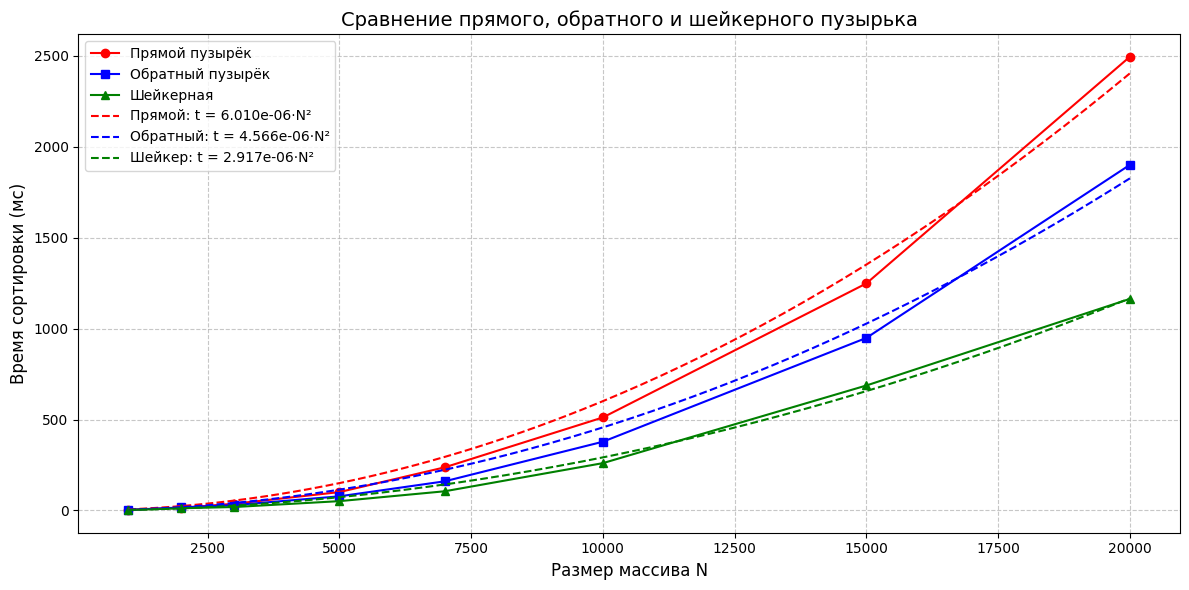

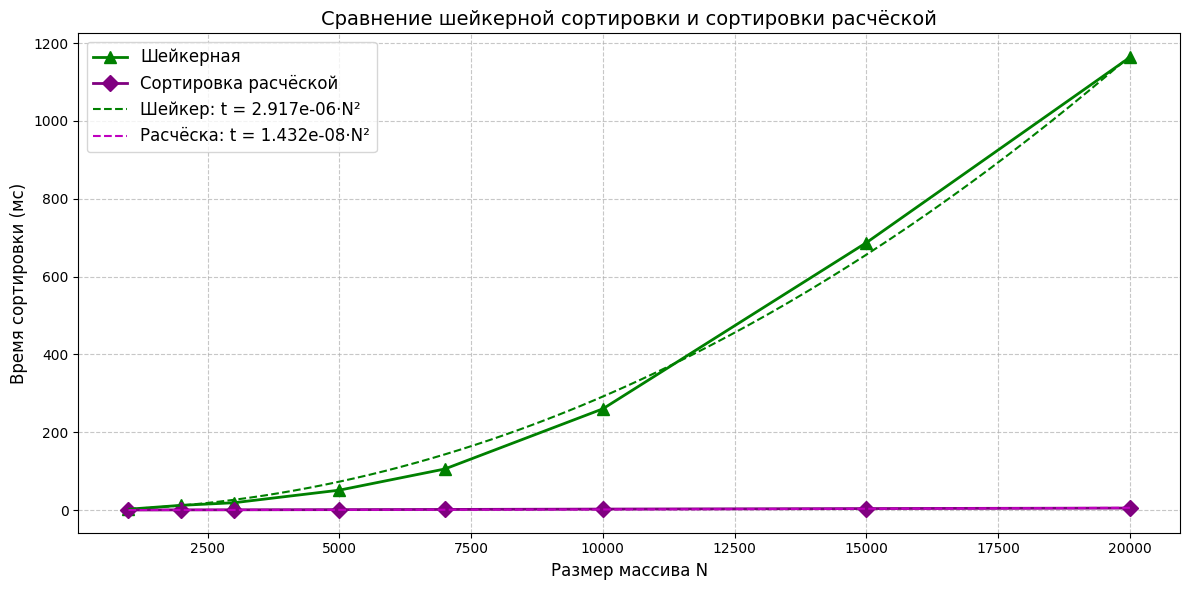

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

# ---------- Чтение данных ----------
df = pd.read_csv('all_sorts_comparison.csv')   # замените на имя вашего файла
N = df['N'].values
t_forward = df['time_forward_ms'].values
t_backward = df['time_backward_ms'].values
t_shaker = df['time_shaker_ms'].values
t_comb = df['time_comb_ms'].values

# ---------- Квадратичная аппроксимация ----------
def quad(x, a):
    return a * x * x

# Для первого графика (три кривые)
a_fwd, _ = curve_fit(quad, N, t_forward)
a_bwd, _ = curve_fit(quad, N, t_backward)
a_shaker1, _ = curve_fit(quad, N, t_shaker)

# Для второго графика (две кривые)
a_shaker2, _ = curve_fit(quad, N, t_shaker)
a_comb, _ = curve_fit(quad, N, t_comb)

N_fit = np.linspace(min(N), max(N), 200)

# ========== ГРАФИК 1: Три первых сортировки ==========
plt.figure(figsize=(12, 6))
plt.plot(N, t_forward, 'o-', label='Прямой пузырёк', color='red', markersize=6)
plt.plot(N, t_backward, 's-', label='Обратный пузырёк', color='blue', markersize=6)
plt.plot(N, t_shaker, '^-', label='Шейкерная', color='green', markersize=6)

# Аппроксимации
plt.plot(N_fit, quad(N_fit, a_fwd), 'r--', label=f'Прямой: t = {a_fwd[0]:.3e}·N²')
plt.plot(N_fit, quad(N_fit, a_bwd), 'b--', label=f'Обратный: t = {a_bwd[0]:.3e}·N²')
plt.plot(N_fit, quad(N_fit, a_shaker1), 'g--', label=f'Шейкер: t = {a_shaker1[0]:.3e}·N²')

plt.xlabel('Размер массива N', fontsize=12)
plt.ylabel('Время сортировки (мс)', fontsize=12)
plt.title('Сравнение прямого, обратного и шейкерного пузырька', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('graph1_bubble_vs_shaker.png', dpi=150)
plt.show()

# ========== ГРАФИК 2: Две последние (шейкер и расчёска) ==========
plt.figure(figsize=(12, 6))
plt.plot(N, t_shaker, '^-', label='Шейкерная', color='green', markersize=8, linewidth=2)
plt.plot(N, t_comb, 'D-', label='Сортировка расчёской', color='purple', markersize=8, linewidth=2)

# Аппроксимации
plt.plot(N_fit, quad(N_fit, a_shaker2), 'g--', label=f'Шейкер: t = {a_shaker2[0]:.3e}·N²')
plt.plot(N_fit, quad(N_fit, a_comb), 'm--', label=f'Расчёска: t = {a_comb[0]:.3e}·N²')

plt.xlabel('Размер массива N', fontsize=12)
plt.ylabel('Время сортировки (мс)', fontsize=12)
plt.title('Сравнение шейкерной сортировки и сортировки расчёской', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('graph2_shaker_vs_comb.png', dpi=150)
plt.show()

